In [87]:
import pandas as pd
import os
import glob
import re
import itertools

# Caminho raiz
base_folder = '../data/processed/model-runs'

# Lista de subpastas (cada uma representa uma língua)
languages = [
    name for name in os.listdir(base_folder)
    if os.path.isdir(os.path.join(base_folder, name))
]

model_results = []

for language in languages:
    folder_path = os.path.join(base_folder, language)
    csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))
    
    for filepath in csv_files:
        filename = os.path.basename(filepath)
        match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
        if not match:
            print(f"Aviso: nome de arquivo inesperado -> {filename}")
            continue

        model_name = match.group(1)
        firac = match.group(2)

        try:
            df = pd.read_csv(filepath)
        except Exception as e:
            print(f"Erro ao ler {filepath}: {e}")
            continue

        # Garante que as colunas esperadas estão presentes
        if 'alternativa' not in df.columns or 'correct' not in df.columns:
            print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
            continue

        total_questions = len(df)
        correct_answers = (df['alternativa'] == df['correct']).sum()
        percentage = correct_answers / total_questions * 100 if total_questions > 0 else 0

        model_results.append({
            'language': language,
            'model': model_name,
            'firac': firac,
            'questões': total_questions,
            'acertos': correct_answers,
            'accuracy': round(percentage, 2)
        })

# Cria DataFrame final
model_results_df = pd.DataFrame(model_results)

# Ordena por modelo e acurácia
model_results_df = model_results_df.sort_values(
    by=['accuracy', 'language', 'model'],
    ascending=[False, False, True]
).reset_index(drop=True)

# ===============================
# ADIÇÃO: completa combinações ausentes
# ===============================

# Cria listas únicas de cada dimensão
all_languages = model_results_df['language'].unique()
all_models = model_results_df['model'].unique()
all_firacs = model_results_df['firac'].unique()

# Gera todas as combinações possíveis
all_combinations = pd.DataFrame(
    itertools.product(all_languages, all_models, all_firacs),
    columns=['language', 'model', 'firac']
)

# Faz merge para adicionar combinações ausentes
model_results_df = (
    all_combinations
    .merge(model_results_df, on=['language', 'model', 'firac'], how='left')
    .fillna({'questões': 0, 'acertos': 0, 'accuracy': ''})
)

# Garante os tipos corretos
model_results_df['questões'] = model_results_df['questões'].astype(int)
model_results_df['acertos'] = model_results_df['acertos'].astype(int)
#model_results_df['accuracy'] = model_results_df['accuracy'].astype(float)

# Reordena
model_results_df = model_results_df.sort_values(
    by=['accuracy','language', 'model', 'firac'], ascending=False,
).reset_index(drop=True)

pd.set_option('display.max_rows', None)


# Exibe resultado final
model_results_df.head(100)


,language,model,firac,questões,acertos,accuracy
0,turkish,gemini-2.5-pro,__R__,0,0,
1,turkish,gemini-2.5-pro,__L__,0,0,
2,turkish,gemini-2.5-flash-lite-preview-06-17,__R__,0,0,
3,turkish,gemini-2.5-flash-lite-preview-06-17,__L__,0,0,
4,turkish,gemini-2.5-flash-lite,__R__,0,0,
5,turkish,gemini-2.5-flash-lite,__L__,0,0,
6,turkish,gemini-2.5-flash,__R__,0,0,
7,turkish,gemini-2.5-flash,__L__,0,0,
8,turkish,gemini-2.0-flash-lite,__R__,0,0,
9,turkish,gemini-2.0-flash-lite,__L__,0,0,


In [88]:
model_results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   language  108 non-null    object
 1   model     108 non-null    object
 2   firac     108 non-null    object
 3   questões  108 non-null    int32 
 4   acertos   108 non-null    int32 
 5   accuracy  108 non-null    object
dtypes: int32(2), object(4)
memory usage: 4.3+ KB


In [89]:
import pandas as pd

# Supondo que o DataFrame se chame model_results_df
# model_results_df = pd.read_csv("seuarquivo.csv")

# Remove registros com NaN na coluna 'accuracy'
model_results_df_clean = model_results_df.dropna(subset=["accuracy"])
model_results_df_clean['accuracy'] = pd.to_numeric(model_results_df_clean['accuracy'], errors='coerce')


# Acurácia média por idioma
accuracy_by_language = (
    model_results_df_clean.groupby("language", as_index=False)["accuracy"]
      .mean()
      .rename(columns={"accuracy": "mean_accuracy"})
      .sort_values("mean_accuracy", ascending=False)
)

# Acurácia média por modelo
accuracy_by_model = (
    model_results_df_clean.groupby("model", as_index=False)["accuracy"]
      .mean()
      .rename(columns={"accuracy": "mean_accuracy"})
      .sort_values("mean_accuracy", ascending=False)
)

# Acurácia média por FIRAC
accuracy_by_firac = (
    model_results_df_clean.groupby("firac", as_index=False)["accuracy"]
      .mean()
      .rename(columns={"accuracy": "mean_accuracy"})
      .sort_values("mean_accuracy", ascending=False)
)

# Exibe resultados
print("Acurácia média por language:")
print(accuracy_by_language, "\n")

print("Acurácia média por model:")
print(accuracy_by_model, "\n")

print("Acurácia média por firac:")
print(accuracy_by_firac)


Acurácia média por language:
     language  mean_accuracy
0  portuguese      85.548148
1     turkish      82.783810 

Acurácia média por model:
                                 model  mean_accuracy
5                       gemini-2.5-pro      96.533750
2                     gemini-2.5-flash      90.692500
0                     gemini-2.0-flash      82.772500
1                gemini-2.0-flash-lite      79.945625
4  gemini-2.5-flash-lite-preview-06-17      78.165625
3                gemini-2.5-flash-lite      77.922500 

Acurácia média por firac:
   firac  mean_accuracy
1  FIRAC      99.603333
2  FIRA_      99.422500
7  __R__      95.290000
3  FIR__      95.110833
0  FIL__      79.184167
4  FI___      77.195000
6  __L__      74.636667
5  F____      70.512500
8   ____      68.718333


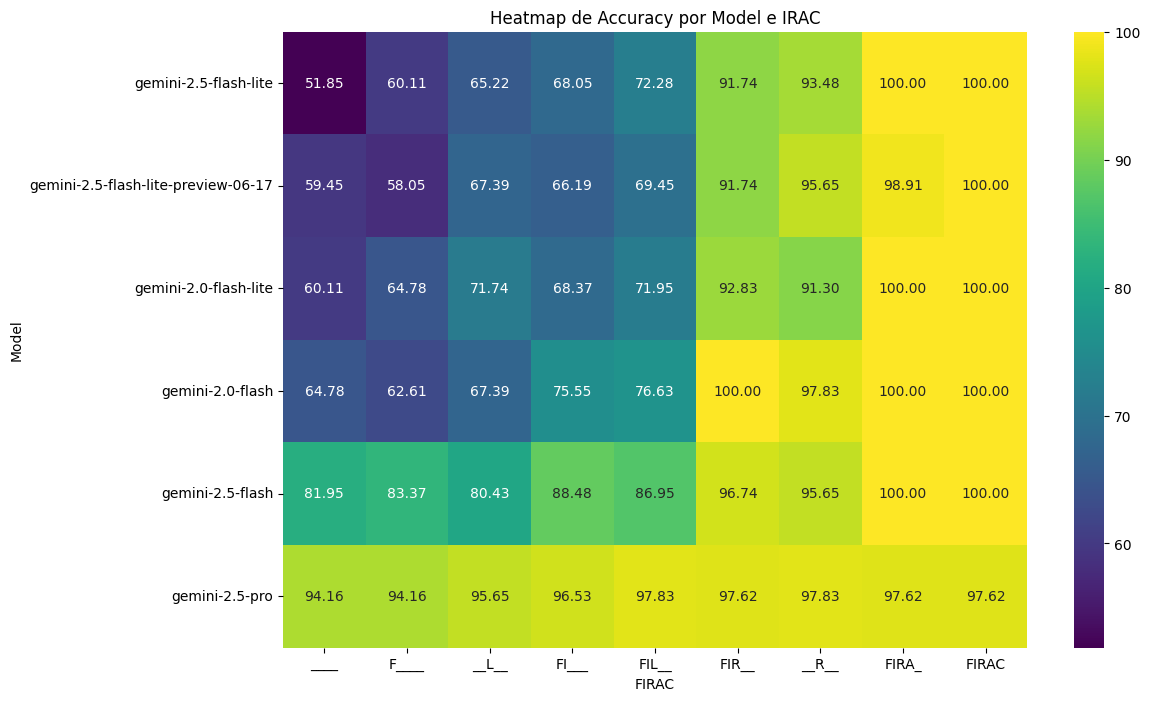

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_results_df_clean = model_results_df[model_results_df.questões > 0]

# Ordenar categorias de X e Y pela média de accuracy
irac_order = model_results_df_clean.groupby('firac')['accuracy'].mean().sort_values().index
model_order = model_results_df_clean.groupby('model')['accuracy'].mean().sort_values().index

# Criar pivot table
heatmap_data = model_results_df_clean.pivot_table(
    index='model',
    columns='firac',
    values='accuracy'
)

# Reordenar linhas e colunas
heatmap_data = heatmap_data.loc[model_order, irac_order]
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')


# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.title("Heatmap de Accuracy por Model e IRAC")
plt.xlabel("FIRAC")
plt.ylabel("Model")
plt.show()


In [91]:
heatmap_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, gemini-2.5-flash-lite to gemini-2.5-pro
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ____    6 non-null      float64
 1   F____   6 non-null      float64
 2   __L__   6 non-null      float64
 3   FI___   6 non-null      float64
 4   FIL__   6 non-null      float64
 5   FIR__   6 non-null      float64
 6   __R__   6 non-null      float64
 7   FIRA_   6 non-null      float64
 8   FIRAC   6 non-null      float64
dtypes: float64(9)
memory usage: 480.0+ bytes


In [92]:
import pandas as pd
import os
import glob
import re

def read_all_dfs(base_folder='../data/processed/model-runs'):
    question_results = []

    # Lista todas as pastas dentro de model-runs (cada pasta é um idioma)
    languages = [name for name in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, name))]

    for language in languages:
        folder_path = os.path.join(base_folder, language)
        csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

        for filepath in csv_files:
            filename = os.path.basename(filepath)
            match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
            if match:
                model_name = match.group(1)
                firac = match.group(2)
            else:
                # Pula arquivos que não seguem o padrão
                continue

            # Lê o CSV
            df = pd.read_csv(filepath)

            # Adiciona colunas extras
            df["model_name"] = model_name
            df["firac"] = firac
            df["language"] = language  # adiciona o idioma

            question_results.append(df)

    # Concatena todos os DataFrames
    final_df = pd.concat(question_results, ignore_index=True)

    # Reordena colunas
    cols = ["model_name", "firac", "language"] + [c for c in final_df.columns if c not in ["model_name", "firac", "language"]]
    final_df = final_df[cols]

    return final_df


In [93]:
full_df = read_all_dfs()
full_df = full_df[full_df['question_id'] != 'oab-226.pdf'].copy()
full_df.head()

,model_name,firac,language,pdf_filename,question_id,materia,prova,questao,enunciado,prompt,A,B,C,D,resposta_completa,alternativa,rule_count,correct,response_time_seconds
0,gemini-2.0-flash-lite,FIL__,portuguese,oab-226.pdf,oab-226.pdf-083,PROCESSO CIVIL,IV,83,"A respeito das ações possessórias, assinale a ...",Resolva a questão do exame da ordem da OAB aba...,A propositura da ação de reintegração de posse...,"Quando for ordenada a justificação prévia, o p...",É vedada a cumulação de pedidos com o pedido p...,O possuidor tem direito a ser mantido na posse...,resposta: [B]\n,NaN,4.0,B,1.317281
1,gemini-2.0-flash-lite,FIL__,portuguese,oab-26.pdf,oab-26.pdf-260,ÉTICA PROFISSIONAL,XXVII,260,"A advogada Mariana, gestante, ao ingressar em ...",Resolva a questão do exame da ordem da OAB aba...,Mariana tem o direito de não ser submetida a a...,Mariana tem o direito de não ser submetida a a...,"Mariana deverá, por medida de segurança, passa...","Mariana tem o direito, independentemente do te...",resposta: B\n,B,1.0,D,0.681947
2,gemini-2.0-flash-lite,FIL__,portuguese,oab-327.pdf,oab-327.pdf-055,PROCESSO DO TRABALHO,V,55,Com relação à competência material da Justiça ...,Resolva a questão do exame da ordem da OAB aba...,"não compete à Justiça do Trabalho, mas à Justi...",é da competência da Justiça do Trabalho o julg...,de acordo com o entendimento do Superior Tribu...,a Justiça do Trabalho é competente para julgar...,resposta: D\n,D,5.0,D,1.288225
3,gemini-2.0-flash-lite,FIL__,portuguese,oab-336.pdf,oab-336.pdf-151,PROCESSO DO TRABALHO,XXXI,151,Você foi contratado(a) para atuar nas seguinte...,Resolva a questão do exame da ordem da OAB aba...,Tanto na ação de cumprimento como na ação plúr...,O sindicato de classe da categoria poderá repr...,"Nas ações plúrima e de cumprimento, a parte au...",O sindicato da categoria poderá representar os...,resposta: D\n,D,6.0,C,1.319898
4,gemini-2.0-flash-lite,FIL__,portuguese,oab-95.pdf,oab-95.pdf-076,DIREITO INTERNACIONAL,XL,76,"Uma sociedade empresária colombiana celebrou, ...",Resolva a questão do exame da ordem da OAB aba...,"A autoridade judiciária inglesa, única e exclu...","A autoridade judiciária colombiana, concorrent...","A autoridade judiciária alemã, única e exclusi...","A autoridade judiciária brasileira, concorrent...",resposta: D\n,D,2.0,D,0.585031


In [94]:
full_df[full_df.question_id == 'oab-60.pdf-141']

,model_name,firac,language,pdf_filename,question_id,materia,prova,questao,enunciado,prompt,A,B,C,D,resposta_completa,alternativa,rule_count,correct,response_time_seconds
9,gemini-2.0-flash-lite,FIL__,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: C\n,C,3.0,D,1.314095
55,gemini-2.0-flash-lite,FIRAC,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: D\n,D,3.0,D,0.708688
101,gemini-2.0-flash-lite,FIRA_,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: D\n,D,3.0,D,1.259015
147,gemini-2.0-flash-lite,FIR__,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: D\n,D,3.0,D,1.245195
193,gemini-2.0-flash-lite,FI___,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: C\n,C,3.0,D,1.251574
239,gemini-2.0-flash-lite,F____,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: C\n,C,3.0,D,1.298028
289,gemini-2.0-flash-lite,__L__,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão juridica abaixo considerando...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: C\n,C,3.0,D,1.209495
335,gemini-2.0-flash-lite,__R__,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão juridica abaixo considerando...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será criminalmente processado somente após o t...,resposta: D\n,D,3.0,D,1.204288
377,gemini-2.0-flash-lite,____,portuguese,oab-60.pdf,oab-60.pdf-141,DIREITO CONSTITUCIONAL,XX,141,"O Presidente da República, após manter áspera ...",Resolva a questão do exame da ordem da OAB aba...,será imediatamente suspenso de suas funções pe...,será imediatamente suspenso de suas funções pe...,"será imediatamente suspenso de suas funções, s...",será crim

In [95]:
import pandas as pd

def calculate_consistency(matrix):
    """
    Calcula o score de consistência de uma matriz binária.

    Regras:
    - Horizontal: andando para a direita, um 1 nunca pode virar 0.
    - Vertical: andando para baixo, um 1 nunca pode virar 0.

    Retorna:
        total_consistency (float): consistência global da matriz
        row_consistency (dict): consistência por linha (chave = model_name)
        col_consistency (dict): consistência por coluna (chave = firac)
    """
    arr = matrix.fillna(0).astype(int).values
    n_rows, n_cols = arr.shape

    # Consistência total
    total_checks, violations = 0, 0

    # Consistência por linha
    row_consistency = {}
    if "model_name" in matrix.index.names or "model_name" in matrix.columns:
        row_labels = matrix.index if matrix.index.name == "model_name" else matrix["model_name"]
    else:
        row_labels = [f"row_{i}" for i in range(n_rows)]

    # Consistência por coluna
    col_labels = matrix.columns if matrix.columns is not None else [f"col_{j}" for j in range(n_cols)]
    col_consistency = {}

    possible_violations = 0
    # --- Horizontal ---
    for i in range(n_rows):
        row_checks, row_violations = 0, 0
        for j in range(n_cols - 1):
            row_checks += 1
            total_checks += 1
            possible_violations += 1
            if arr[i, j] == 1 and arr[i, j+1] == 0:
                violations += 1
                row_violations += 1
        row_consistency[row_labels[i]] = row_violations

    # --- Vertical ---
    for j in range(n_cols):
        col_checks, col_violations = 0, 0
        for i in range(n_rows - 1):
            col_checks += 1
            total_checks += 1
            possible_violations += 1
            
            if arr[i, j] == 1 and arr[i+1, j] == 0:
                violations += 1
                col_violations += 1
        col_consistency[col_labels[j]] = col_violations

    return possible_violations, violations, row_consistency, col_consistency



def extract_question_matrix(question_id, language, final_df):
    """
    Gera uma matriz de 1s e 0s com acerto/erro da questão por (modelo, irac),
    ordenando linhas e colunas pela acurácia média global.

    Retorna:
        matrix (pd.DataFrame): matriz binária
        consistency (float): score entre 0 e 1
    """
    # ---- calcula acurácia global ----
    final_df = final_df.copy()
    final_df['is_correct'] = (final_df['alternativa'] == final_df['correct']).astype(int)

    model_acc = final_df.groupby('model_name')['is_correct'].mean().sort_values(ascending=True)
    irac_acc = final_df.groupby('firac')['is_correct'].mean().sort_values(ascending=True)

    # ---- filtra questão específica ----
    df_q = final_df[final_df['question_id'] == question_id].copy()
    df_q = df_q[df_q['language'] == language].copy()
    # cria matriz
    matrix = df_q.pivot_table(
        index="model_name",
        columns="firac",
        values="is_correct",
        aggfunc="first"
    )

    # ---- reordena linhas e colunas pela acurácia média ----
    matrix = matrix.loc[matrix.index.intersection(model_acc.index)]
    matrix = matrix.loc[model_acc.index]
    matrix = matrix[irac_acc.index.intersection(matrix.columns)]

    # ---- calcula consistência ----
    possible_violations, total_violations, model_consistency, firac_consistency = calculate_consistency(matrix)

    return matrix, possible_violations, total_violations, model_consistency, firac_consistency


{'gemini-2.5-flash-lite': 0, 'gemini-2.5-flash-lite-preview-06-17': 2, 'gemini-2.0-flash-lite': 0, 'gemini-2.0-flash': 0, 'gemini-2.5-flash': 0, 'gemini-2.5-pro': 1}
{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 1, 'FIL__': 1, '__R__': 0, 'FIR__': 0, 'FIRA_': 0, 'FIRAC': 0}


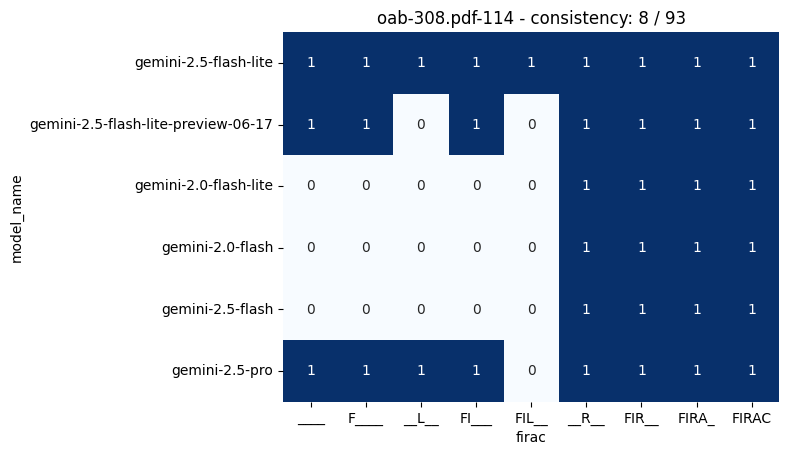

firac                                ____  F____  __L__  FI___  FIL__  __R__  \
model_name                                                                     
gemini-2.5-flash-lite                   1      1      1      1      1      1   
gemini-2.5-flash-lite-preview-06-17     1      1      0      1      0      1   
gemini-2.0-flash-lite                   0      0      0      0      0      1   
gemini-2.0-flash                        0      0      0      0      0      1   
gemini-2.5-flash                        0      0      0      0      0      1   
gemini-2.5-pro                          1      1      1      1      0      1   

firac                                FIR__  FIRA_  FIRAC  
model_name                                                
gemini-2.5-flash-lite                    1      1      1  
gemini-2.5-flash-lite-preview-06-17      1      1      1  
gemini-2.0-flash-lite                    1      1      1  
gemini-2.0-flash                         1      1      1  
gemin

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

qid = "oab-308.pdf-114"

matrix, possible_violations, total_violations, model_consistency, firac_consistency = extract_question_matrix(qid, 'portuguese', full_df)

print(model_consistency)
print(firac_consistency)

sns.heatmap(matrix, annot=True, cmap="Blues", cbar=False)
plt.title(f"{qid} - consistency: {total_violations} / {possible_violations}")
plt.show()


print(matrix)

In [97]:
import pandas as pd
from tqdm import tqdm

# Supondo que você já tenha full_df e extract_question_matrix definido

results = []
question_matrixes = [ ]

for qid in tqdm(full_df['question_id'].unique(), desc="Processando questões"):
    try:
        # Invoca a função para cada question_id
        matrix, possible_violations, total_violations, model_consistency, firac_consistency = extract_question_matrix(qid, 'portuguese', full_df)

        question_matrixes.append(matrix)

        # Armazena os resultados em um dicionário
        results.append({
            'question_id': qid,
            'possible_violations': possible_violations,
            'total_violations': total_violations,
            'model_consistency': model_consistency,
            'firac_consistency': firac_consistency
        })
    except Exception as e:
        print(f"Erro ao processar question_id {qid}: {e}")

# Converte a lista de dicionários em DataFrame
consistency_df = pd.DataFrame(results)

consistency_df.sort_values(by='total_violations', ascending=False)


Processando questões: 100%|██████████| 46/46 [00:00<00:00, 104.91it/s]


,question_id,possible_violations,total_violations,model_consistency,firac_consistency
22,oab-333.pdf-114,93,10,"{'gemini-2.5-flash-lite': 2, 'gemini-2.5-flash...","{'____': 1, 'F____': 0, '__L__': 1, 'FI___': 0..."
39,oab-115.pdf-168,93,10,"{'gemini-2.5-flash-lite': 1, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 1..."
17,oab-170.pdf-180,93,9,"{'gemini-2.5-flash-lite': 0, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 2..."
27,oab-55.pdf-088,93,9,"{'gemini-2.5-flash-lite': 0, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 1..."
11,oab-182.pdf-006,93,8,"{'gemini-2.5-flash-lite': 0, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 0..."
3,oab-336.pdf-151,93,8,"{'gemini-2.5-flash-lite': 1, 'gemini-2.5-flash...","{'____': 0, 'F____': 1, '__L__': 2, 'FI___': 1..."
31,oab-292.pdf-210,93,8,"{'gemini-2.5-flash-lite': 2, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 0, 'FI___': 1..."
20,oab-308.pdf-114,93,8,"{'gemini-2.5-flash-lite': 0, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 1, 'FI___': 1..."
15,oab-211.pdf-128,93,8,"{'gemini-2.5-flash-lite': 1, 'gemini-2.5-flash...","{'____': 0, 'F____': 1, '__L__': 1, 'FI___': 1..."
36,oab-24.pdf-241,93,8,"{'gemini-2.5-flash-lite': 2, 'gemini-2.5-flash...","{'____': 1, 'F____': 1, '__L__': 0, 'FI___': 1..."


In [98]:
question_matrixes[0].columns

X = [df.to_numpy().flatten() for df in question_matrixes]

X

[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [99]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Passo 1: normaliza e achata cada matriz ---
X = []
for df in question_matrixes:
    arr = StandardScaler().fit_transform(df.to_numpy())  # normaliza cada matriz
    X.append(arr.flatten())

X = np.vstack(X)  # cada linha = uma matriz

# --- Passo 2: K-Means com 2 clusters ---
K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

print('clusters', X)

'''
# --- Passo 3: print dos clusters ---
for c in range(K):
    print(f"\n=== Cluster {c} ===")
    for i, df in enumerate(question_matrixes):
        if clusters[i] == c:
            plt.figure(figsize=(6, 4))
            sns.heatmap(df, annot=True, cmap="coolwarm", cbar=True)
            plt.title(f"{df.index.name or 'Matriz'} {i} (Cluster {c})")
            plt.show()
'''

clusters [[ 0.          0.          0.4472136  ...  0.          0.
   0.        ]
 [-0.70710678  1.         -0.70710678 ...  1.          0.
   0.        ]
 [ 0.4472136   0.4472136   0.4472136  ...  0.          0.
   0.        ]
 ...
 [ 0.4472136   0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -2.23606798 ...  0.          0.
   0.        ]]


'\n# --- Passo 3: print dos clusters ---\nfor c in range(K):\n    print(f"\n=== Cluster {c} ===")\n    for i, df in enumerate(question_matrixes):\n        if clusters[i] == c:\n            plt.figure(figsize=(6, 4))\n            sns.heatmap(df, annot=True, cmap="coolwarm", cbar=True)\n            plt.title(f"{df.index.name or \'Matriz\'} {i} (Cluster {c})")\n            plt.show()\n'

In [100]:
import pandas as pd

# Supondo que consistency_df já exista

# Extrai as colunas de model_consistency para colunas separadas
model_consistency_df = consistency_df['model_consistency'].apply(pd.Series)

# Adiciona a coluna question_id para manter referência
model_consistency_df = pd.concat([consistency_df[['question_id']], model_consistency_df], axis=1)

# Soma de cada coluna (ignorando question_id)
model_sums = model_consistency_df.drop(columns=['question_id']).sum()

# Visualiza as somas
print(model_sums)


gemini-2.5-flash-lite                  24
gemini-2.5-flash-lite-preview-06-17    22
gemini-2.0-flash-lite                   9
gemini-2.0-flash                        8
gemini-2.5-flash                       27
gemini-2.5-pro                          7
dtype: int64


In [101]:
import pandas as pd

# Supondo que consistency_df já exista

# Extrai as colunas de firac_consistency para colunas separadas
firac_consistency_df = consistency_df['firac_consistency'].apply(pd.Series)

# Adiciona a coluna question_id para referência
firac_consistency_df = pd.concat([consistency_df[['question_id']], firac_consistency_df], axis=1)

# Soma de cada coluna (ignorando question_id)
firac_sums = firac_consistency_df.drop(columns=['question_id']).sum()

# Visualiza as somas
print(firac_sums)


____     19
F____    23
__L__    16
FI___    17
FIL__    19
__R__     7
FIR__     5
FIRA_     1
FIRAC     0
dtype: int64


In [102]:
def get_eligible_questions(full_df):
    """
    Retorna uma lista de question_id que foram avaliadas para todos os pares (model_name, firac).
    """
    # conjunto de todos os pares possíveis
    all_pairs = set(full_df[['language', 'model_name', 'firac']].drop_duplicates().itertuples(index=False, name=None))
    n_pairs = len(all_pairs)

    # conta pares únicos por questão
    pair_counts = (
        full_df.groupby('question_id')[['language', 'model_name', 'firac']]
        .apply(lambda x: len(set(x.itertuples(index=False, name=None))))
    )

    # mantém apenas questões com todos os pares
    eligible_questions = pair_counts[pair_counts == n_pairs].index.tolist()

    return eligible_questions


eligeble_questions = get_eligible_questions(full_df)
print('#eligeble', len(eligeble_questions))

eligeble_questions

#eligeble 20


['oab-112.pdf-140',
 'oab-170.pdf-180',
 'oab-179.pdf-276',
 'oab-181.pdf-288',
 'oab-182.pdf-006',
 'oab-185.pdf-033',
 'oab-189.pdf-081',
 'oab-201.pdf-030',
 'oab-211.pdf-128',
 'oab-226.pdf-083',
 'oab-26.pdf-260',
 'oab-28.pdf-275',
 'oab-282.pdf-105',
 'oab-283.pdf-115',
 'oab-316.pdf-196',
 'oab-327.pdf-055',
 'oab-336.pdf-151',
 'oab-60.pdf-141',
 'oab-7.pdf-067',
 'oab-95.pdf-076']

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_question_matrices(final_df):
    """
    Plota uma matriz para cada question_id, ordenados pela acurácia média da questão.
    """
    # calcula acurácia média de cada questão
    final_df = final_df.copy()
    final_df['is_correct'] = (final_df['alternativa'] == final_df['correct']).astype(int)
    question_acc = final_df.groupby('question_id')['is_correct'].mean().sort_values(ascending=False)

    # plota cada questão
    for qid in get_eligible_questions(final_df):
        matrix, consistency = extract_question_matrix(qid, final_df)

        print('qid', qid, consistency)
        #print(matrix)
        #print()

        #plt.figure(figsize=(8, 6))
        #sns.heatmap(matrix, annot=True, cmap="Blues", cbar=False, linewidths=0.5, linecolor="gray")
        #plt.title(f"Questão {qid} (Acurácia média: {question_acc[qid]:.2f})")
        #plt.ylabel("Modelos")
        #plt.xlabel("IRAC")
        #plt.tight_layout()
        #plt.show()

# Exemplo: gera plots de todas as questões
#plot_all_question_matrices(full_df)


In [104]:
import pandas as pd
import os
import glob
import re

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/portuguese'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

# Lista para guardar os resultados de cada questão
question_results = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        firac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if 'alternativa' not in df.columns or 'correct' not in df.columns or 'question_id' not in df.columns:
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Para cada questão, calcula se a resposta está correta
    for _, row in df.iterrows():
        is_correct = int(row['alternativa'] == row['correct'])
        question_results.append({
            'question_id': row['question_id'],
            'materia': row['materia'],
            'firac': firac,
            'model': model_name,
            'acertos': is_correct
        })

# Cria DataFrame com os resultados
question_results_df = pd.DataFrame(question_results)

# Calcula métricas agregadas por questão
question_results_df = question_results_df.groupby(['question_id', 'materia', 'firac']).agg(
    acertos_total=('acertos', 'sum'),
    total_modelos=('acertos', 'count'),
    accuracy=('acertos', 'mean')
).reset_index()

# Ordena por question_id e accuracy
question_results_df = question_results_df.sort_values(by=['question_id', 'accuracy'], ascending=False)

question_results_df.head(300)


,question_id,materia,firac,acertos_total,total_modelos,accuracy
406,oab-99.pdf-009,DIREITO TRIBUTÁRIO,FIRAC,6,6,1.000000
407,oab-99.pdf-009,DIREITO TRIBUTÁRIO,FIRA_,6,6,1.000000
408,oab-99.pdf-009,DIREITO TRIBUTÁRIO,FIR__,6,6,1.000000
412,oab-99.pdf-009,DIREITO TRIBUTÁRIO,__R__,5,6,0.833333
405,oab-99.pdf-009,DIREITO TRIBUTÁRIO,FIL__,4,6,0.666667
409,oab-99.pdf-009,DIREITO TRIBUTÁRIO,FI___,2,6,0.333333
410,oab-99.pdf-009,DIREITO TRIBUTÁRIO,F____,2,6,0.333333
411,oab-99.pdf-009,DIREITO TRIBUTÁRIO,__L__,2,6,0.333333
413,oab-99.pdf-009,DIREITO TRIBUTÁRIO,____,2,6,0.333333
396,oab-95.pdf-076,DIREITO INTERNACIONAL,FIL__,6,6,1.000000


In [105]:
question_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 414 entries, 406 to 4
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   question_id    414 non-null    object 
 1   materia        414 non-null    object 
 2   firac          414 non-null    object 
 3   acertos_total  414 non-null    int64  
 4   total_modelos  414 non-null    int64  
 5   accuracy       414 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 22.6+ KB


In [106]:
import pandas as pd

# Cria pivot table
question_accuracy_pivot = question_results_df.pivot(
    index=['question_id', 'materia'],
    columns='firac',
    values='accuracy'
)

# Calcula a média de acurácia por coluna e ordena as colunas
col_order = question_accuracy_pivot.mean().sort_values(ascending=True).index
question_accuracy_pivot = question_accuracy_pivot[col_order]

# Ordena primeiro por '____' e em caso de empate, desempata por 'F____'
question_accuracy_pivot = question_accuracy_pivot.sort_values(by=['____', 'F____'], ascending=[False, False])

# Remove linhas com NaN
question_accuracy_df = question_accuracy_pivot.dropna()

# Visualiza top 20
question_accuracy_df.head(100)


,firac,____,F____,__L__,FIL__,FI___,__R__,FIR__,FIRA_,FIRAC
question_id,materia,,,,,,,,,
oab-13.pdf-123,ÉTICA PROFISSIONAL,1.000000,1.000000,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-167.pdf-149,DIREITO CIVIL,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-189.pdf-079,ECA,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-189.pdf-081,ECA,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-201.pdf-030,DIREITO EMPRESARIAL,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-226.pdf-083,PROCESSO CIVIL,1.000000,1.000000,0.833333,0.833333,1.000000,1.000000,1.000000,1.000000,1.0
oab-279.pdf-072,PROCESSO PENAL,1.000000,1.000000,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-295.pdf-001,DIREITO PREVIDENCIÁRIO,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
oab-316.pdf-196,DIREITO DO TRABALHO,1.000000,1.000000,1.000000,0.833333,1.000000,1.000000,1.000000,1.000000,1.0


In [107]:
question_accuracy_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 46 entries, ('oab-13.pdf-123', 'ÉTICA PROFISSIONAL') to ('oab-60.pdf-141', 'DIREITO CONSTITUCIONAL')
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ____    46 non-null     float64
 1   F____   46 non-null     float64
 2   __L__   46 non-null     float64
 3   FIL__   46 non-null     float64
 4   FI___   46 non-null     float64
 5   __R__   46 non-null     float64
 6   FIR__   46 non-null     float64
 7   FIRA_   46 non-null     float64
 8   FIRAC   46 non-null     float64
dtypes: float64(9)
memory usage: 5.5+ KB


In [ ]:
question_accuracy_df.info()

In [109]:
import pandas as pd

# Cria uma coluna temporária 'materia_temp' com o segundo nível do MultiIndex
question_accuracy_df = question_accuracy_df.copy()
question_accuracy_df['materia_temp'] = [idx[1] for idx in question_accuracy_df.index]

# Agrupa por matéria e calcula a média de todas as colunas de acurácia
materia_df = question_accuracy_df.groupby('materia_temp')[['____', 'FI___', 'F____', 'FIL__', 'FIR__', 'FIRAC', 'FIRA_']].mean()

# Mostra o resultado
materia_df.sort_values(by='____')


firac,____,FI___,F____,FIL__,FIR__,FIRAC,FIRA_
materia_temp,,,,,,,
DIREITO CONSTITUCIONAL,0.500000,0.722222,0.555556,0.666667,1.000000,1.0,1.000000
DIREITO TRIBUTÁRIO,0.541667,0.625000,0.500000,0.791667,0.916667,1.0,0.958333
DIREITO DO TRABALHO,0.625000,0.750000,0.625000,0.625000,1.000000,1.0,1.000000
PROCESSO DO TRABALHO,0.633333,0.733333,0.700000,0.600000,1.000000,1.0,1.000000
PROCESSO PENAL,0.733333,0.700000,0.666667,0.733333,0.866667,1.0,1.000000
DIREITO EMPRESARIAL,0.750000,0.833333,0.833333,0.750000,1.000000,1.0,1.000000
ÉTICA PROFISSIONAL,0.750000,0.770833,0.729167,0.729167,0.895833,1.0,1.000000
DIREITO CIVIL,0.800000,0.900000,0.933333,0.933333,1.000000,1.0,1.000000
DIREITO INTERNACIONAL,0.833333,1.000000,0.833333,1.000000,1.000000,1.0,1.000000


In [110]:
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px

# Supondo que seu DataFrame se chame question_accuracy_df

# Extrai question_id e materia do MultiIndex
question_accuracy_df = question_accuracy_df.copy()
question_accuracy_df["question_id"] = [idx[0] for idx in question_accuracy_df.index]
question_accuracy_df["materia"] = question_accuracy_df["materia_temp"]

# Seleciona colunas numéricas (as acurácias)
X = question_accuracy_df[["____", "F____", "__L__", "FIL__", "FI___", "__R__", "FIR__", "FIRA_", "FIRAC"]].values

# Executa o t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate=100,
    random_state=42
)
X_embedded = tsne.fit_transform(X)

# Cria DataFrame com coordenadas do t-SNE
tsne_df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "materia": question_accuracy_df["materia"],
    "question_id": question_accuracy_df["question_id"]
})

# Gráfico interativo com Plotly
fig = px.scatter(
    tsne_df,
    x="x",
    y="y",
    color="materia",
    hover_data=["question_id", "materia"],
    title="t-SNE das Questões da OAB por Padrão de Acurácia (FIRAC)",
    width=900,
    height=600
)

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(legend_title_text="Matéria", legend=dict(x=1, y=1))

fig.show()


In [ ]:
question_accuracy_df.columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

source_category = '____'
target_category = 'FIL__'

# Cria coluna temporária com a matéria (segundo elemento da tupla do Index)
question_accuracy_df = question_accuracy_df.copy()
question_accuracy_df['materia_temp'] = [idx[1] for idx in question_accuracy_df.index]

# Calcula a média da acurácia por matéria
materia_means = question_accuracy_df.groupby('materia_temp')[[source_category, target_category]].mean().reset_index()
materia_means = materia_means.sort_values(by=source_category, ascending=True)

# Plot do gráfico pirulito
plt.figure(figsize=(10, 8))

# Adiciona pontos para legenda apenas
plt.scatter([], [], color='red', s=100, label=source_category)
plt.scatter([], [], color='blue', s=100, label=target_category)

# Plot cada linha e os pontos
for i, row in materia_means.iterrows():
    plt.plot([row[source_category], row[target_category]], [row['materia_temp'], row['materia_temp']], color='grey', lw=2, zorder=1)
    plt.scatter(row[source_category], row['materia_temp'], color='red', s=100, zorder=2)
    plt.scatter(row[target_category], row['materia_temp'], color='blue', s=100, zorder=2)

plt.xlabel("Acurácia média")
plt.ylabel("Matéria")
plt.title(f"acurácia média por matéria ({source_category} vs {target_category})")
plt.legend(title='Categoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
import os
import glob
import re
import json

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/portuguese/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

# Lista para guardar todos os dados juntos
all_data = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if not {'alternativa', 'correct', 'question_id'}.issubset(df.columns):
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Adiciona colunas de metadados
    df['modelo'] = model_name
    df['irac'] = irac
    df['acertou'] = df['alternativa'] == df['correct']


    # Armazena os dados
    all_data.append(df)

# Junta todos os dados em um único DataFrame
questions_df = pd.concat(all_data, ignore_index=True)

questions_df.head()

In [ ]:
questions_df.columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# exemplo de DataFrame
# questions_df = pd.DataFrame({
#     'materia': ['Matemática', 'História', 'Matemática', 'Física', 'História', 'Física'],
#     'acertou': [True, False, True, True, True, False]
# })

# calcular acurácia por matéria
accuracy_by_materia = questions_df.groupby("materia")["acertou"].mean().sort_values()

# plotar histograma horizontal
plt.figure(figsize=(8, 5))
accuracy_by_materia.plot(kind="barh", color="skyblue", edgecolor="black")

plt.xlabel("Accuracy")
plt.ylabel("Topic")
plt.title("Accuracy by Topic")
plt.xlim(0, 1)  # porque acurácia vai de 0 a 1
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()


In [ ]:
# Calcula a acurácia e média de rule_count por question_id e materia
accuracy_by_question_df = (
    questions_df.groupby(['question_id', 'materia'])
    .agg(acurácia=('acertou', 'mean'),
         rule_count=('rule_count', 'mean'))
    .reset_index()
    .sort_values(by='acurácia', ascending=False)
)

# Exibe as 100 últimas linhas (menor acurácia)
accuracy_by_question_df.tail(100)


In [ ]:

# Contagem e porcentagem de alternativas por questão
counts = questions_df.groupby(['question_id', 'alternativa']).size().reset_index(name='count')
total_per_question = counts.groupby('question_id')['count'].transform('sum')
counts['percentage'] = (counts['count'] / total_per_question) * 100

# Pivot com alternativas como colunas
percentage_df = counts.pivot(index='question_id', columns='alternativa', values='percentage').fillna(0)

# Adiciona coluna 'correct'
correct_values = questions_df.groupby('question_id')['correct'].first()
percentage_df = percentage_df.merge(correct_values, on='question_id').reset_index()


percentage_df.head()

In [ ]:
analysis_df = percentage_df.merge(accuracy_by_question_df, on='question_id', how='inner')
analysis_df = analysis_df.sort_values(by='acurácia', ascending=False)

analysis_df

In [ ]:
import matplotlib.pyplot as plt

# Plot de boxplot diretamente a partir do DataFrame original
plt.figure(figsize=(10, 6))
accuracy_by_question_df.boxplot(
    column='acurácia',
    by='rule_count',
    grid=False,
    showfliers=False  # oculta outliers, opcional
)

plt.xlabel('Número de regras extraídas (rule_count)')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por número de regras extraídas')
plt.suptitle('')  # Remove o título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calcula a ordem das matérias pela média da acurácia (maior para menor)
materia_order = (
    accuracy_by_question_df.groupby('materia')['acurácia']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Reordena o DataFrame conforme essa ordem
accuracy_sorted_df = accuracy_by_question_df.copy()
accuracy_sorted_df['materia'] = pd.Categorical(
    accuracy_sorted_df['materia'],
    categories=materia_order,
    ordered=True
)

# Plot do boxplot
plt.figure(figsize=(10, 6))
accuracy_sorted_df.boxplot(
    column='acurácia',
    by='materia',
    grid=False,
    showfliers=False  # oculta outliers
)

plt.xlabel('Matéria')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por matéria')
plt.suptitle('')  # Remove título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gira os labels do eixo X para vertical
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
